# SchoolBridge 시장 분석 시각화 v2
## 개선 포인트: #11 제주 · #15 경주 데이터 재평가 및 활용

---

### 재평가 배경

기존 v1에서 제주(#11)와 경주(#15) 데이터는 "대표성 부족", "소도시 특수 사례"를 이유로 제외했습니다.
그러나 이는 SchoolBridge의 핵심 논거와 모순됩니다.

> **핵심 논거 (발표 슬라이드 1-2③)**: "학생 적은 지역 = 학교 행정 인력 부족 → 번역된 통신문 미제공 가능성 높음"

이 논리라면 제주·경주처럼 다문화 학생이 **적은 지역**이야말로 행정 자원이 없어 AI 자동화가 더 절실한 곳입니다.
두 데이터셋을 **"소외된 지방의 서비스 필요성"** 근거로 재포지셔닝해 활용합니다.

| # | 파일명 | 변경 | 이유 |
|---|--------|------|------|
| 11 | 제주특별자치도_다문화가구현황_20231231.csv | ❌→✅ 활용 | 결혼이민자 3,032명 (2023), 2016→2023 증가 추세 — 지방 소외 지역 서비스 필요성 근거 |
| 15 | 경상북도 경주시_다문화가족 현황_20230822.csv | ❌→✅ 활용 | 결혼이민자 1,037명, 23개 읍면동 세분화 — 지방 내 불균형 및 소도시 서비스 긴급성 근거 |

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = r'C:\Users\kysop\Team_Project_Multiculture\multicultural-ai\model\classification\Business_Plan\By_region\\'
print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 기존 활용 데이터 로딩 (v1과 동일)

In [6]:
# ── 파일 2: 서울 다문화 학생 현황 ──────────────────────────────────
df_seoul_student_raw = pd.read_csv(
    DATA_DIR + '다문화가정+학생+현황_20260524195948.csv',
    encoding='utf-8', header=None
)
col_region = df_seoul_student_raw.iloc[2:, 0].reset_index(drop=True)
col_subregion = df_seoul_student_raw.iloc[2:, 1].reset_index(drop=True)
elem_total = pd.to_numeric(df_seoul_student_raw.iloc[2:, 2].reset_index(drop=True), errors='coerce')
elem_intermarriage = pd.to_numeric(df_seoul_student_raw.iloc[2:, 3].reset_index(drop=True), errors='coerce')
elem_foreign = pd.to_numeric(df_seoul_student_raw.iloc[2:, 4].reset_index(drop=True), errors='coerce')

df_seoul_student = pd.DataFrame({
    '시도': col_region, '구': col_subregion,
    '초등_합계': elem_total, '초등_국제결혼': elem_intermarriage, '초등_외국인': elem_foreign,
})
df_gu = df_seoul_student.dropna(subset=['초등_합계']).copy()
df_gu = df_gu[~df_gu['구'].isin(['소계', '합계'])].reset_index(drop=True)
df_gu['초등_합계'] = df_gu['초등_합계'].astype(int)
df_gu = df_gu.sort_values('초등_합계', ascending=False).reset_index(drop=True)

# ── 파일 9: 강원도 외국인 현황 ──────────────────────────────────────
df_gangwon_raw = pd.read_csv(
    DATA_DIR + '외국인_국적별_현황_20260524201426.csv',
    encoding='cp949', header=None
)
regions = df_gangwon_raw.iloc[2:, 0].reset_index(drop=True)
total = pd.to_numeric(df_gangwon_raw.iloc[2:, 1].reset_index(drop=True), errors='coerce')
df_gangwon = pd.DataFrame({'지역': regions, '합계': total})
df_gangwon = df_gangwon.dropna(subset=['합계']).reset_index(drop=True)

print('기존 데이터 로드 완료')

기존 데이터 로드 완료


---
## 2. 신규 활용 데이터 로딩 (#11 제주 · #15 경주)

In [7]:
# ── 파일 11: 제주 다문화가구현황 (2016-2023 추세) ─────────────────────
# 재평가: 전국 하위권 지역이지만 결혼이민자 꾸준히 증가 → 행정 자원 없이 홀로 감당
df_jeju = pd.read_csv(
    DATA_DIR + '제주특별자치도_다문화가구현황_20231231.csv',
    encoding='cp949'
)
df_jeju.columns = ['연도', '다문화가구', '내국인_출생', '내국인_귀화', '외국인_결혼이민자', '외국인_기타', '자료', '기준일']
df_jeju = df_jeju[['연도', '다문화가구', '내국인_귀화', '외국인_결혼이민자', '외국인_기타']].copy()
for col in ['다문화가구', '내국인_귀화', '외국인_결혼이민자', '외국인_기타']:
    df_jeju[col] = pd.to_numeric(df_jeju[col], errors='coerce')

print('=== #11 제주 다문화가구현황 (2016-2023) ===')
print(df_jeju.to_string(index=False))
jeju_growth = (df_jeju['외국인_결혼이민자'].iloc[-1] / df_jeju['외국인_결혼이민자'].iloc[0] - 1) * 100
print(f'\n결혼이민자 증가율 (2016→2023): +{jeju_growth:.1f}%')

=== #11 제주 다문화가구현황 (2016-2023) ===
  연도  다문화가구  내국인_귀화  외국인_결혼이민자  외국인_기타
2016   3959    1523       2271     389
2017   4276    1711       2443     371
2018   4686    1874       2583     398
2019   5072    2099       2719     490
2020   5415    2303       2870     497
2021   5730    2456       2903     499
2022   5958    2596       2932     537
2023   6164    2718       3032     606

결혼이민자 증가율 (2016→2023): +33.5%


In [8]:
# ── 파일 15: 경주시 다문화가족 현황 (읍면동별) ──────────────────────────
# 재평가: 학생 수 변수 없지만 결혼이민자 1,037명 분포 확인 가능 → 지방 내 불균형 근거
df_gyeongju = pd.read_csv(
    DATA_DIR + '경상북도 경주시_다문화가족 현황_20230822.csv',
    encoding='cp949'
)
df_gyeongju.columns = [
    '구분', '합계', '한국인배우자', '결혼이민자', '귀화자',
    '자녀외국출생', '자녀국내출생', '동거인내국인', '동거인외국인'
]

# CP949 CSV는 셀 값에 앞뒤 공백이 붙는 경우가 있으므로 제거
df_gyeongju['구분'] = df_gyeongju['구분'].str.strip()

# 경주시 전체 행 분리
df_gyeongju_total = df_gyeongju[df_gyeongju['구분'] == '경주시'].copy()
df_gyeongju_dong = df_gyeongju[df_gyeongju['구분'] != '경주시'].copy()

for col in ['합계', '결혼이민자', '귀화자', '자녀국내출생']:
    df_gyeongju_dong[col] = pd.to_numeric(df_gyeongju_dong[col], errors='coerce')

df_gyeongju_dong = df_gyeongju_dong.dropna(subset=['결혼이민자']).reset_index(drop=True)
df_gyeongju_dong = df_gyeongju_dong.sort_values('결혼이민자', ascending=False).reset_index(drop=True)

print('=== #15 경주시 다문화가족 현황 (읍면동별) ===')
print(f'경주시 전체 다문화가족: {int(df_gyeongju_total["합계"].values[0]):,}명')
print(f'결혼이민자: {int(df_gyeongju_total["결혼이민자"].values[0]):,}명')
print(f'귀화자: {int(df_gyeongju_total["귀화자"].values[0]):,}명')
print()
print('읍면동별 결혼이민자 상위 10:')
print(df_gyeongju_dong[['구분', '결혼이민자', '합계']].head(10).to_string(index=False))

=== #15 경주시 다문화가족 현황 (읍면동별) ===
경주시 전체 다문화가족: 6,288명
결혼이민자: 1,037명
귀화자: 928명

읍면동별 결혼이민자 상위 10:
 구분  결혼이민자   합계
외동읍    323 1407
안강읍     77  661
성건동     75  391
황성동     68  405
동천동     65  433
용강동     55  370
선도동     47  282
현곡면     46  324
불국동     41  240
건천읍     27  225


---
## 3. 신규 시각화: 지방 소외 지역 — 행정 자원 없는 곳이 더 절실하다

### 3-1. 제주도 다문화가구 구성원 추세 (2016-2023) — 소외 지방도 증가 중

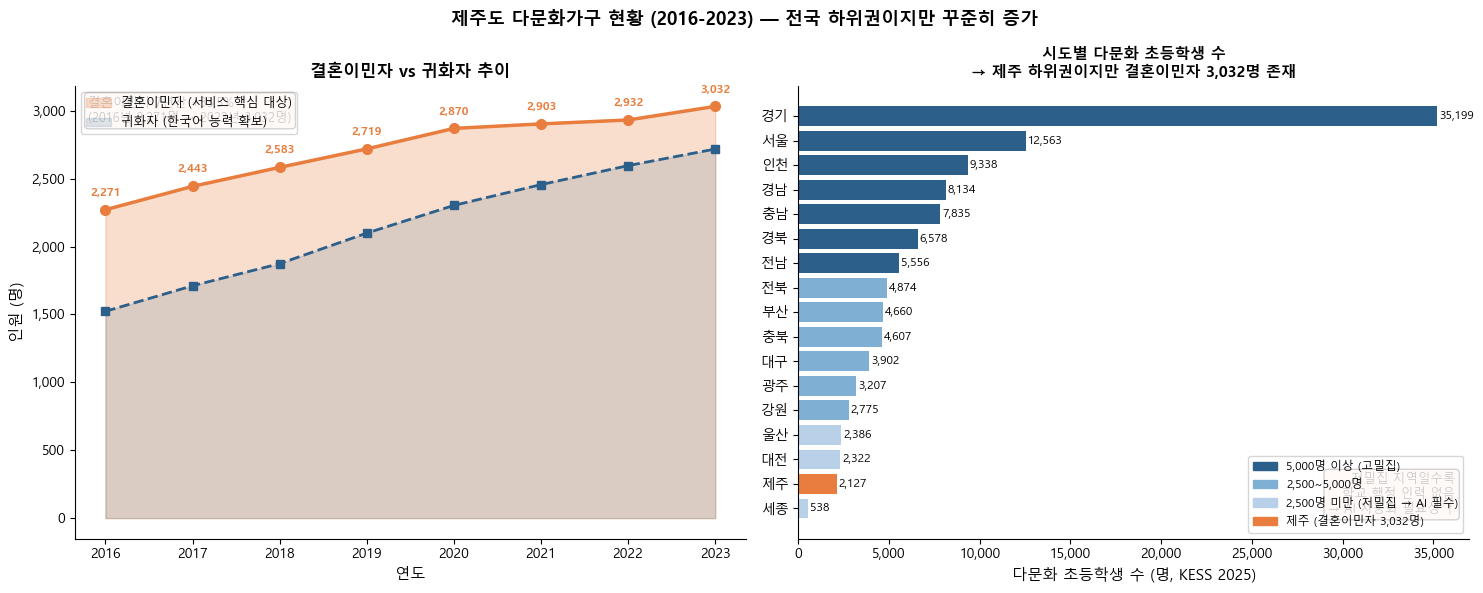

✅ 제주 추세 시각화 완료


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('제주도 다문화가구 현황 (2016-2023) — 전국 하위권이지만 꾸준히 증가',
             fontsize=13, fontweight='bold')

# ── 좌: 결혼이민자 + 귀화자 추세 ────────────────────────────────────
ax1 = axes[0]

ax1.fill_between(df_jeju['연도'], df_jeju['외국인_결혼이민자'],
                  alpha=0.25, color='#E87D3E', label='결혼이민자 (서비스 핵심 대상)')
ax1.plot(df_jeju['연도'], df_jeju['외국인_결혼이민자'],
          marker='o', color='#E87D3E', linewidth=2.5, markersize=7)

ax1.fill_between(df_jeju['연도'], df_jeju['내국인_귀화'],
                  alpha=0.15, color='#2C5F8A', label='귀화자 (한국어 능력 확보)')
ax1.plot(df_jeju['연도'], df_jeju['내국인_귀화'],
          marker='s', color='#2C5F8A', linewidth=2, markersize=6, linestyle='--')

for _, row in df_jeju.iterrows():
    ax1.annotate(f"{int(row['외국인_결혼이민자']):,}",
                  (row['연도'], row['외국인_결혼이민자']),
                  textcoords='offset points', xytext=(0, 10),
                  ha='center', fontsize=8.5, color='#E87D3E', fontweight='bold')

ax1.set_xlabel('연도', fontsize=11)
ax1.set_ylabel('인원 (명)', fontsize=11)
ax1.set_title('결혼이민자 vs 귀화자 추이', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks(df_jeju['연도'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 증가율 주석
growth_mi = (df_jeju['외국인_결혼이민자'].iloc[-1] / df_jeju['외국인_결혼이민자'].iloc[0] - 1) * 100
ax1.text(0.02, 0.92,
          f'결혼이민자 7년간 +{growth_mi:.1f}%\n(2016년 {int(df_jeju["외국인_결혼이민자"].iloc[0]):,}명 → 2023년 {int(df_jeju["외국인_결혼이민자"].iloc[-1]):,}명)',
          transform=ax1.transAxes, fontsize=9,
          bbox=dict(boxstyle='round', facecolor='#FFE8D6', alpha=0.85))

# ── 우: 전국 다문화 학생 수 스펙트럼 vs 제주 위치 ──────────────────
ax2 = axes[1]

# KESS 2025 시도별 데이터 (발표 자료 기반) + 제주 추가
provinces = ['경기', '서울', '인천', '경남', '충남', '경북', '전남', '전북',
             '부산', '충북', '대구', '광주', '강원', '울산', '대전', '제주', '세종']
students = [35199, 12563, 9338, 8134, 7835, 6578, 5556, 4874,
            4660, 4607, 3902, 3207, 2775, 2386, 2322, 2127, 538]

colors_prov = ['#E87D3E' if p == '제주' else
               '#2C5F8A' if students[i] >= 5000 else
               '#7FAFD3' if students[i] >= 2500 else '#B8D0E8'
               for i, p in enumerate(provinces)]

sorted_data = sorted(zip(students, provinces, colors_prov), key=lambda x: x[0])
s_students, s_provinces, s_colors = zip(*sorted_data)

bars2 = ax2.barh(s_provinces, s_students, color=s_colors)
for bar, val in zip(bars2, s_students):
    ax2.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
              f'{val:,}', va='center', fontsize=8.5)

ax2.set_xlabel('다문화 초등학생 수 (명, KESS 2025)', fontsize=11)
ax2.set_title('시도별 다문화 초등학생 수\n→ 제주 하위권이지만 결혼이민자 3,032명 존재', fontsize=11, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

high_patch = mpatches.Patch(color='#2C5F8A', label='5,000명 이상 (고밀집)')
mid_patch = mpatches.Patch(color='#7FAFD3', label='2,500~5,000명')
low_patch = mpatches.Patch(color='#B8D0E8', label='2,500명 미만 (저밀집 → AI 필수)')
jeju_patch = mpatches.Patch(color='#E87D3E', label='제주 (결혼이민자 3,032명)')
ax2.legend(handles=[high_patch, mid_patch, low_patch, jeju_patch], fontsize=8.5, loc='lower right')

ax2.text(0.98, 0.05,
          '저밀집 지역일수록\n학교 행정 인력 없음\n→ AI 자동화 필요성 ↑',
          transform=ax2.transAxes, ha='right', va='bottom', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='#FFE8D6', alpha=0.85))

plt.tight_layout()
plt.savefig('chart_v2_1_jeju_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 제주 추세 시각화 완료')

### 3-2. 경주시 읍면동별 결혼이민자 분포 — 지방 소도시 내 불균형

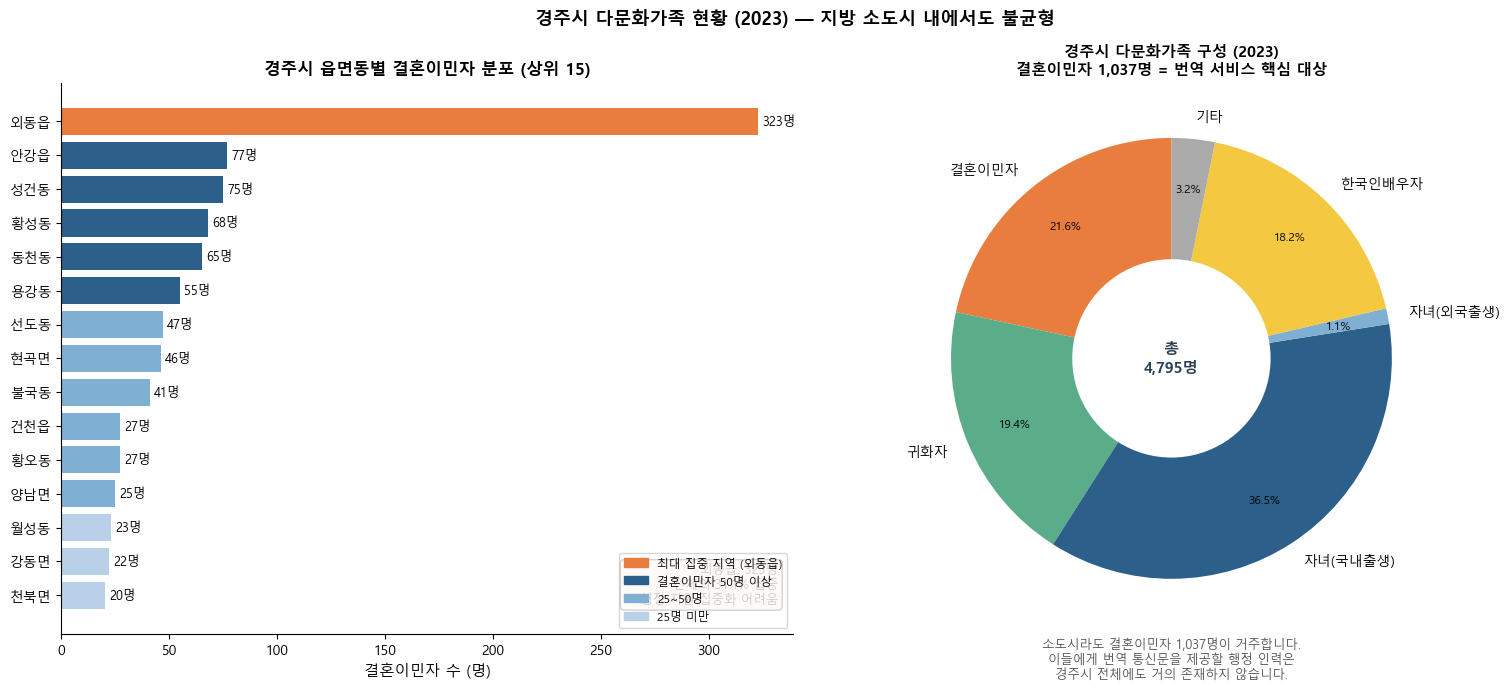

✅ 경주시 분포 시각화 완료


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('경주시 다문화가족 현황 (2023) — 지방 소도시 내에서도 불균형',
             fontsize=13, fontweight='bold')

# ── 좌: 읍면동별 결혼이민자 수 ──────────────────────────────────────
ax1 = axes[0]
top_dong = df_gyeongju_dong.head(15).copy()
top_dong = top_dong.sort_values('결혼이민자', ascending=True)

max_val = top_dong['결혼이민자'].max()
bar_colors = ['#E87D3E' if v == max_val else
               '#2C5F8A' if v >= 50 else
               '#7FAFD3' if v >= 25 else '#B8D0E8'
               for v in top_dong['결혼이민자']]

bars1 = ax1.barh(top_dong['구분'], top_dong['결혼이민자'], color=bar_colors)
for bar, val in zip(bars1, top_dong['결혼이민자']):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
              f'{int(val):,}명', va='center', fontsize=9)

ax1.set_xlabel('결혼이민자 수 (명)', fontsize=11)
ax1.set_title('경주시 읍면동별 결혼이민자 분포 (상위 15)', fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

top_dong_name = df_gyeongju_dong.iloc[0]['구분']
top_dong_val = int(df_gyeongju_dong.iloc[0]['결혼이민자'])
total_mi = int(df_gyeongju_total['결혼이민자'].values[0])
top_ratio = top_dong_val / total_mi * 100

ax1.text(0.98, 0.05,
          f'{top_dong_name}: {top_dong_val}명\n전체의 {top_ratio:.1f}% 집중\n→ 행정 지원 집중화 어려움',
          transform=ax1.transAxes, ha='right', va='bottom', fontsize=9,
          bbox=dict(boxstyle='round', facecolor='#FFE8D6', alpha=0.85))

high_p = mpatches.Patch(color='#E87D3E', label=f'최대 집중 지역 ({top_dong_name})')
mid_p = mpatches.Patch(color='#2C5F8A', label='결혼이민자 50명 이상')
low_p = mpatches.Patch(color='#7FAFD3', label='25~50명')
vl_p = mpatches.Patch(color='#B8D0E8', label='25명 미만')
ax1.legend(handles=[high_p, mid_p, low_p, vl_p], fontsize=8.5, loc='lower right')

# ── 우: 경주시 다문화가족 구성 도넛 + 지방 소도시 비교 ─────────────
ax2 = axes[1]

total_row = df_gyeongju_total.iloc[0]
categories = {
    '결혼이민자': int(total_row['결혼이민자']),
    '귀화자': int(total_row['귀화자']),
    '자녀(국내출생)': int(total_row['자녀국내출생']),
    '자녀(외국출생)': int(total_row['자녀외국출생']),
    '한국인배우자': int(total_row['한국인배우자']),
    '기타': int(total_row['동거인외국인']),
}

colors_cat = ['#E87D3E', '#5BAD8A', '#2C5F8A', '#7FAFD3', '#F5C842', '#AAAAAA']
wedges, texts, autotexts = ax2.pie(
    list(categories.values()),
    labels=list(categories.keys()),
    colors=colors_cat,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.55),
    pctdistance=0.77
)
for at in autotexts:
    at.set_fontsize(8.5)

total_val = sum(categories.values())
mi_val = categories['결혼이민자']
ax2.text(0, 0, f'총\n{total_val:,}명', ha='center', va='center',
          fontsize=11, fontweight='bold', color='#2C3E50')

ax2.set_title(f'경주시 다문화가족 구성 (2023)\n결혼이민자 {mi_val:,}명 = 번역 서비스 핵심 대상',
               fontsize=11, fontweight='bold')

ax2.text(0, -1.45,
          '소도시라도 결혼이민자 1,037명이 거주합니다.\n'
          '이들에게 번역 통신문을 제공할 행정 인력은\n'
          '경주시 전체에도 거의 존재하지 않습니다.',
          ha='center', fontsize=9, color='#555', style='italic')

plt.tight_layout()
plt.savefig('chart_v2_2_gyeongju_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 경주시 분포 시각화 완료')

### 3-3. 핵심 통합 차트: "전국 어디서나 필요하다" — 수도권 고밀집부터 지방 소도시까지

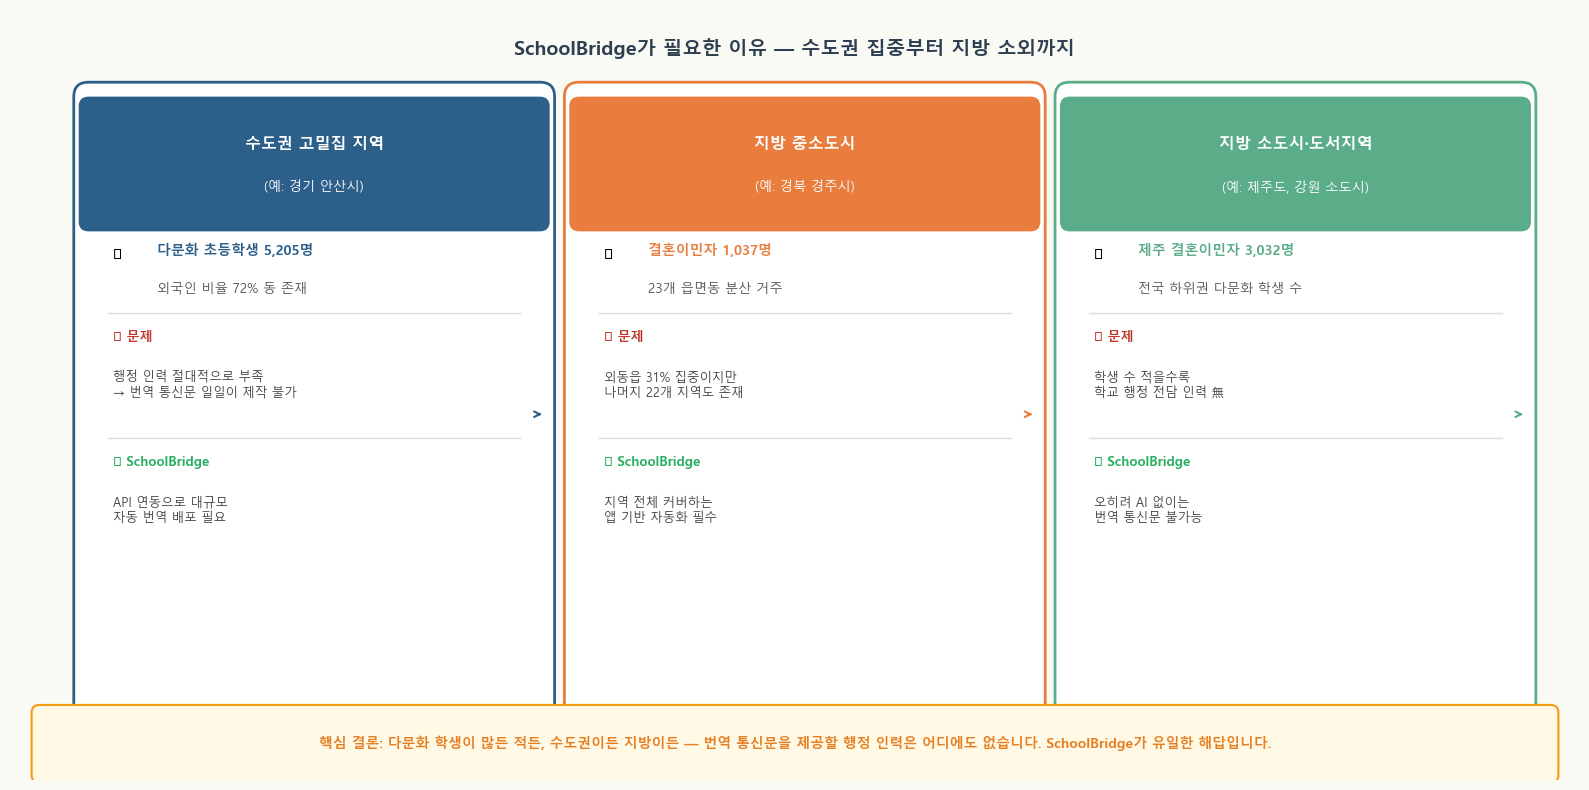

✅ 전국 필요성 통합 차트 완료


In [11]:
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis('off')
fig.patch.set_facecolor('#FAFAF5')

# 제목
ax.text(8, 7.6, 'SchoolBridge가 필요한 이유 — 수도권 집중부터 지방 소외까지',
         ha='center', va='center', fontsize=14, fontweight='bold', color='#2C3E50')

# 3개 카드 레이아웃
card_data = [
    {
        'title': '수도권 고밀집 지역',
        'subtitle': '(예: 경기 안산시)',
        'stat1': '다문화 초등학생 5,205명',
        'stat2': '외국인 비율 72% 동 존재',
        'problem': '행정 인력 절대적으로 부족\n→ 번역 통신문 일일이 제작 불가',
        'solution': 'API 연동으로 대규모\n자동 번역 배포 필요',
        'color': '#2C5F8A',
        'x': 0.8
    },
    {
        'title': '지방 중소도시',
        'subtitle': '(예: 경북 경주시)',
        'stat1': '결혼이민자 1,037명',
        'stat2': '23개 읍면동 분산 거주',
        'problem': '외동읍 31% 집중이지만\n나머지 22개 지역도 존재',
        'solution': '지역 전체 커버하는\n앱 기반 자동화 필수',
        'color': '#E87D3E',
        'x': 5.8
    },
    {
        'title': '지방 소도시·도서지역',
        'subtitle': '(예: 제주도, 강원 소도시)',
        'stat1': '제주 결혼이민자 3,032명',
        'stat2': '전국 하위권 다문화 학생 수',
        'problem': '학생 수 적을수록\n학교 행정 전담 인력 無',
        'solution': '오히려 AI 없이는\n번역 통신문 불가능',
        'color': '#5BAD8A',
        'x': 10.8
    }
]

for card in card_data:
    x = card['x']
    # 카드 배경
    box = mpatches.FancyBboxPatch((x, 0.6), 4.6, 6.5,
                                    boxstyle='round,pad=0.15',
                                    facecolor='white', edgecolor=card['color'], linewidth=2)
    ax.add_patch(box)

    # 헤더 배경
    header = mpatches.FancyBboxPatch((x, 5.8), 4.6, 1.2,
                                      boxstyle='round,pad=0.1',
                                      facecolor=card['color'], edgecolor='none', linewidth=0)
    ax.add_patch(header)

    # 제목
    ax.text(x + 2.3, 6.6, card['title'],
             ha='center', va='center', fontsize=11.5, fontweight='bold', color='white')
    ax.text(x + 2.3, 6.15, card['subtitle'],
             ha='center', va='center', fontsize=9.5, color='white')

    # 통계
    ax.text(x + 0.25, 5.45, '📊', ha='left', va='center', fontsize=10)
    ax.text(x + 0.7, 5.5, card['stat1'],
             ha='left', va='center', fontsize=10, fontweight='bold', color=card['color'])
    ax.text(x + 0.7, 5.1, card['stat2'],
             ha='left', va='center', fontsize=9.5, color='#555')

    # 구분선
    ax.plot([x + 0.2, x + 4.4], [4.85, 4.85], color='#ddd', linewidth=1)

    # 문제
    ax.text(x + 0.25, 4.6, '⚠ 문제', ha='left', va='center', fontsize=9.5,
             color='#C0392B', fontweight='bold')
    ax.text(x + 0.25, 4.1, card['problem'],
             ha='left', va='center', fontsize=9, color='#444')

    # 구분선
    ax.plot([x + 0.2, x + 4.4], [3.55, 3.55], color='#ddd', linewidth=1)

    # 해결
    ax.text(x + 0.25, 3.3, '✅ SchoolBridge', ha='left', va='center', fontsize=9.5,
             color='#27AE60', fontweight='bold')
    ax.text(x + 0.25, 2.8, card['solution'],
             ha='left', va='center', fontsize=9, color='#444')

    # 화살표
    ax.annotate('', xy=(x + 4.65, 3.8), xytext=(x + 4.55, 3.8),
                 arrowprops=dict(arrowstyle='->', color=card['color'], lw=1.5))

# 하단 핵심 메시지
msg_box = mpatches.FancyBboxPatch((0.3, 0.05), 15.4, 0.65,
                                    boxstyle='round,pad=0.08',
                                    facecolor='#FFF9E6', edgecolor='#F39C12', linewidth=1.5)
ax.add_patch(msg_box)
ax.text(8, 0.38,
         '핵심 결론: 다문화 학생이 많든 적든, 수도권이든 지방이든 — 번역 통신문을 제공할 행정 인력은 어디에도 없습니다. SchoolBridge가 유일한 해답입니다.',
         ha='center', va='center', fontsize=10, fontweight='bold', color='#E67E22')

plt.tight_layout()
plt.savefig('chart_v2_3_nationwide_need.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 전국 필요성 통합 차트 완료')

### 3-4. 지방 소도시 결혼이민자 규모 비교 — 제주·경주도 무시할 수 없는 숫자

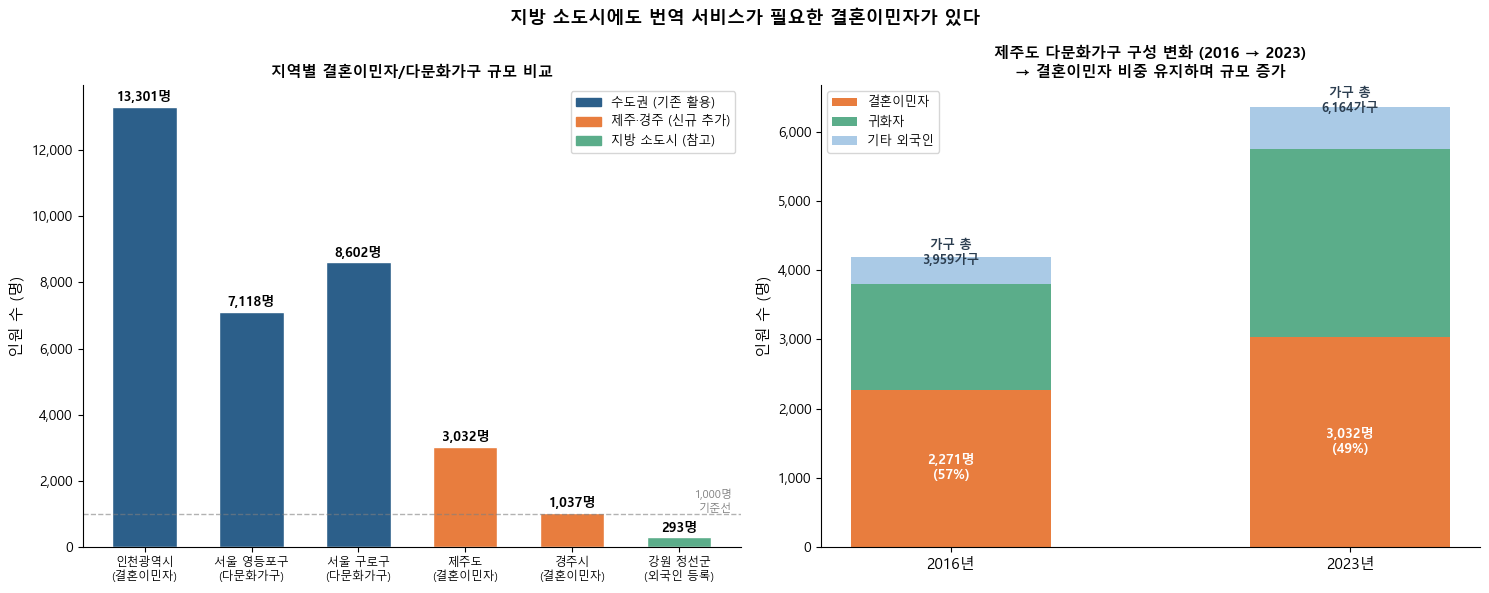

✅ 지방 소도시 비교 시각화 완료


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('지방 소도시에도 번역 서비스가 필요한 결혼이민자가 있다',
             fontsize=13, fontweight='bold')

# ── 좌: 지역별 결혼이민자 규모 비교 ────────────────────────────────
ax1 = axes[0]

# 비교 데이터 (각 데이터 출처: 공공데이터 + KESS)
compare_regions = [
    '인천광역시\n(결혼이민자)',
    '서울 영등포구\n(다문화가구)',
    '서울 구로구\n(다문화가구)',
    '제주도\n(결혼이민자)',  # #11 활용
    '경주시\n(결혼이민자)',  # #15 활용
    '강원 정선군\n(외국인 등록)',
]
compare_values = [13301, 7118, 8602, 3032, 1037, 293]
compare_colors = ['#2C5F8A', '#2C5F8A', '#2C5F8A', '#E87D3E', '#E87D3E', '#5BAD8A']
compare_labels = ['수도권', '수도권', '수도권', '#11 제주 (신규)', '#15 경주 (신규)', '지방 소도시']

bars1 = ax1.bar(range(len(compare_regions)), compare_values,
                 color=compare_colors, width=0.6, edgecolor='white')

for i, (bar, val) in enumerate(zip(bars1, compare_values)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
              f'{val:,}명', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# 수평선: 1,000명 기준
ax1.axhline(y=1000, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.text(5.5, 1050, '1,000명\n기준선', fontsize=8, color='gray', ha='right')

ax1.set_xticks(range(len(compare_regions)))
ax1.set_xticklabels(compare_regions, fontsize=8.5)
ax1.set_ylabel('인원 수 (명)', fontsize=11)
ax1.set_title('지역별 결혼이민자/다문화가구 규모 비교', fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

metro_patch = mpatches.Patch(color='#2C5F8A', label='수도권 (기존 활용)')
new_patch = mpatches.Patch(color='#E87D3E', label='제주·경주 (신규 추가)')
rural_patch = mpatches.Patch(color='#5BAD8A', label='지방 소도시 (참고)')
ax1.legend(handles=[metro_patch, new_patch, rural_patch], fontsize=9)

# ── 우: 제주 다문화가구 구성 변화 (2016 vs 2023) ────────────────────
ax2 = axes[1]

years = ['2016년', '2023년']
mi_vals = [int(df_jeju['외국인_결혼이민자'].iloc[0]),
            int(df_jeju['외국인_결혼이민자'].iloc[-1])]
naturalized_vals = [int(df_jeju['내국인_귀화'].iloc[0]),
                     int(df_jeju['내국인_귀화'].iloc[-1])]
other_vals = [int(df_jeju['외국인_기타'].iloc[0]),
               int(df_jeju['외국인_기타'].iloc[-1])]
total_households = [int(df_jeju['다문화가구'].iloc[0]),
                     int(df_jeju['다문화가구'].iloc[-1])]

x_pos = np.arange(len(years))
width = 0.5

bar_mi = ax2.bar(x_pos, mi_vals, width, label='결혼이민자', color='#E87D3E')
bar_nat = ax2.bar(x_pos, naturalized_vals, width, bottom=mi_vals,
                   label='귀화자', color='#5BAD8A')
bar_other = ax2.bar(x_pos, other_vals, width,
                     bottom=[m+n for m,n in zip(mi_vals, naturalized_vals)],
                     label='기타 외국인', color='#AACAE6')

for i, (total, mi) in enumerate(zip(total_households, mi_vals)):
    ax2.text(i, mi / 2, f'{mi:,}명\n({mi/total*100:.0f}%)',
              ha='center', va='center', fontsize=9.5, color='white', fontweight='bold')

for i, total in enumerate(total_households):
    ax2.text(i, total + 80, f'가구 총\n{total:,}가구',
              ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2C3E50')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(years, fontsize=11)
ax2.set_ylabel('인원 수 (명)', fontsize=11)
ax2.set_title('제주도 다문화가구 구성 변화 (2016 → 2023)\n→ 결혼이민자 비중 유지하며 규모 증가',
               fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('chart_v2_4_jeju_gyeongju_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 지방 소도시 비교 시각화 완료')

---
## 4. 데이터 활용 종합 요약 (v2 업데이트)

In [13]:
summary_v2 = {
    '# (원본)': [1,2,3,4,5,6,7,8,9, '11 (신규)', '15 (신규)'],
    '데이터': [
        '서울 다문화가구 구별 통계',
        '서울 다문화학생 현황',
        '서울 다문화가족 현황',
        '서울 외국인과의 혼인',
        '경기도교육청 다문화학생현황',
        '경기도 안산시 외국인현황',
        '인천 외국인 국적별 등록현황',
        '인천 다문화가족 통계',
        '강원 외국인 등록현황',
        '제주 다문화가구현황 (재평가)',
        '경주시 다문화가족 현황 (재평가)',
    ],
    '활용': ['✅']*9 + ['✅ (v2 신규)', '✅ (v2 신규)'],
    '핵심 인사이트': [
        '구간 격차 수십 배 → 행정 지원 불균등',
        '초등 다문화 12,563명 (서울)',
        '결혼이민자 = 1차 서비스 타겟',
        '9개 언어 73%+ 커버',
        '경기 35,199명, 안산 집중',
        '외국인 비율 30%+ 동 존재',
        '5년간 22% 증가 추세',
        '구간 격차 수십 배',
        '지방 내 외국인 분산 → AI 필요성',
        '결혼이민자 3,032명 (2023), 7년간 +33.5% 증가 → 지방도 성장 중',
        '결혼이민자 1,037명 + 23개 읍면동 불균형 → 소도시도 서비스 절실',
    ]
}

df_summary_v2 = pd.DataFrame(summary_v2)
print('=== v2 데이터 활용 종합 요약 ===')
print(df_summary_v2.to_string(index=False))

print('\n=== 재평가 결과 ===')
print('✅ #11 제주: 결혼이민자 3,032명 (2023), 7년간 +33.5% 증가')
print('   → "소외 지역"이 아닌 "행정 인력 없는 성장 지역" → SchoolBridge 필요성 직접 근거')
print()
print('✅ #15 경주: 결혼이민자 1,037명, 23개 읍면동 세분화')
print('   → "특수 사례"가 아닌 "지방 소도시의 전형" → 전국 서비스 확장 근거')
print()
print('⚠ 두 데이터셋 공통 한계: 초등학생 수 직접 변수 없음')
print('   → 결혼이민자 수를 잠재적 서비스 대상 하한으로 사용 (학생 자녀가 있는 가정 일부)')

=== v2 데이터 활용 종합 요약 ===
 # (원본)                데이터        활용                                       핵심 인사이트
      1     서울 다문화가구 구별 통계         ✅                        구간 격차 수십 배 → 행정 지원 불균등
      2        서울 다문화학생 현황         ✅                           초등 다문화 12,563명 (서울)
      3        서울 다문화가족 현황         ✅                             결혼이민자 = 1차 서비스 타겟
      4        서울 외국인과의 혼인         ✅                                 9개 언어 73%+ 커버
      5     경기도교육청 다문화학생현황         ✅                             경기 35,199명, 안산 집중
      6      경기도 안산시 외국인현황         ✅                              외국인 비율 30%+ 동 존재
      7    인천 외국인 국적별 등록현황         ✅                                 5년간 22% 증가 추세
      8        인천 다문화가족 통계         ✅                                    구간 격차 수십 배
      9        강원 외국인 등록현황         ✅                          지방 내 외국인 분산 → AI 필요성
11 (신규)   제주 다문화가구현황 (재평가) ✅ (v2 신규) 결혼이민자 3,032명 (2023), 7년간 +33.5% 증가 → 지방도 성장 중
15 (신규) 경주시 다문화가족 현황 (재평가) ✅ (v2 신규)      결혼이민자 1,037명 + 23개 읍면